/tmp/ipykernel_580352/2204044825.py:60: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter = ax1.scatter(df_station['Mean_flux_trap_mgC_m2_j'],
/tmp/ipykernel_580352/2204044825.py:119: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter = ax2.scatter(df_station['Mean_flux_trap_mgC_m2_j'],


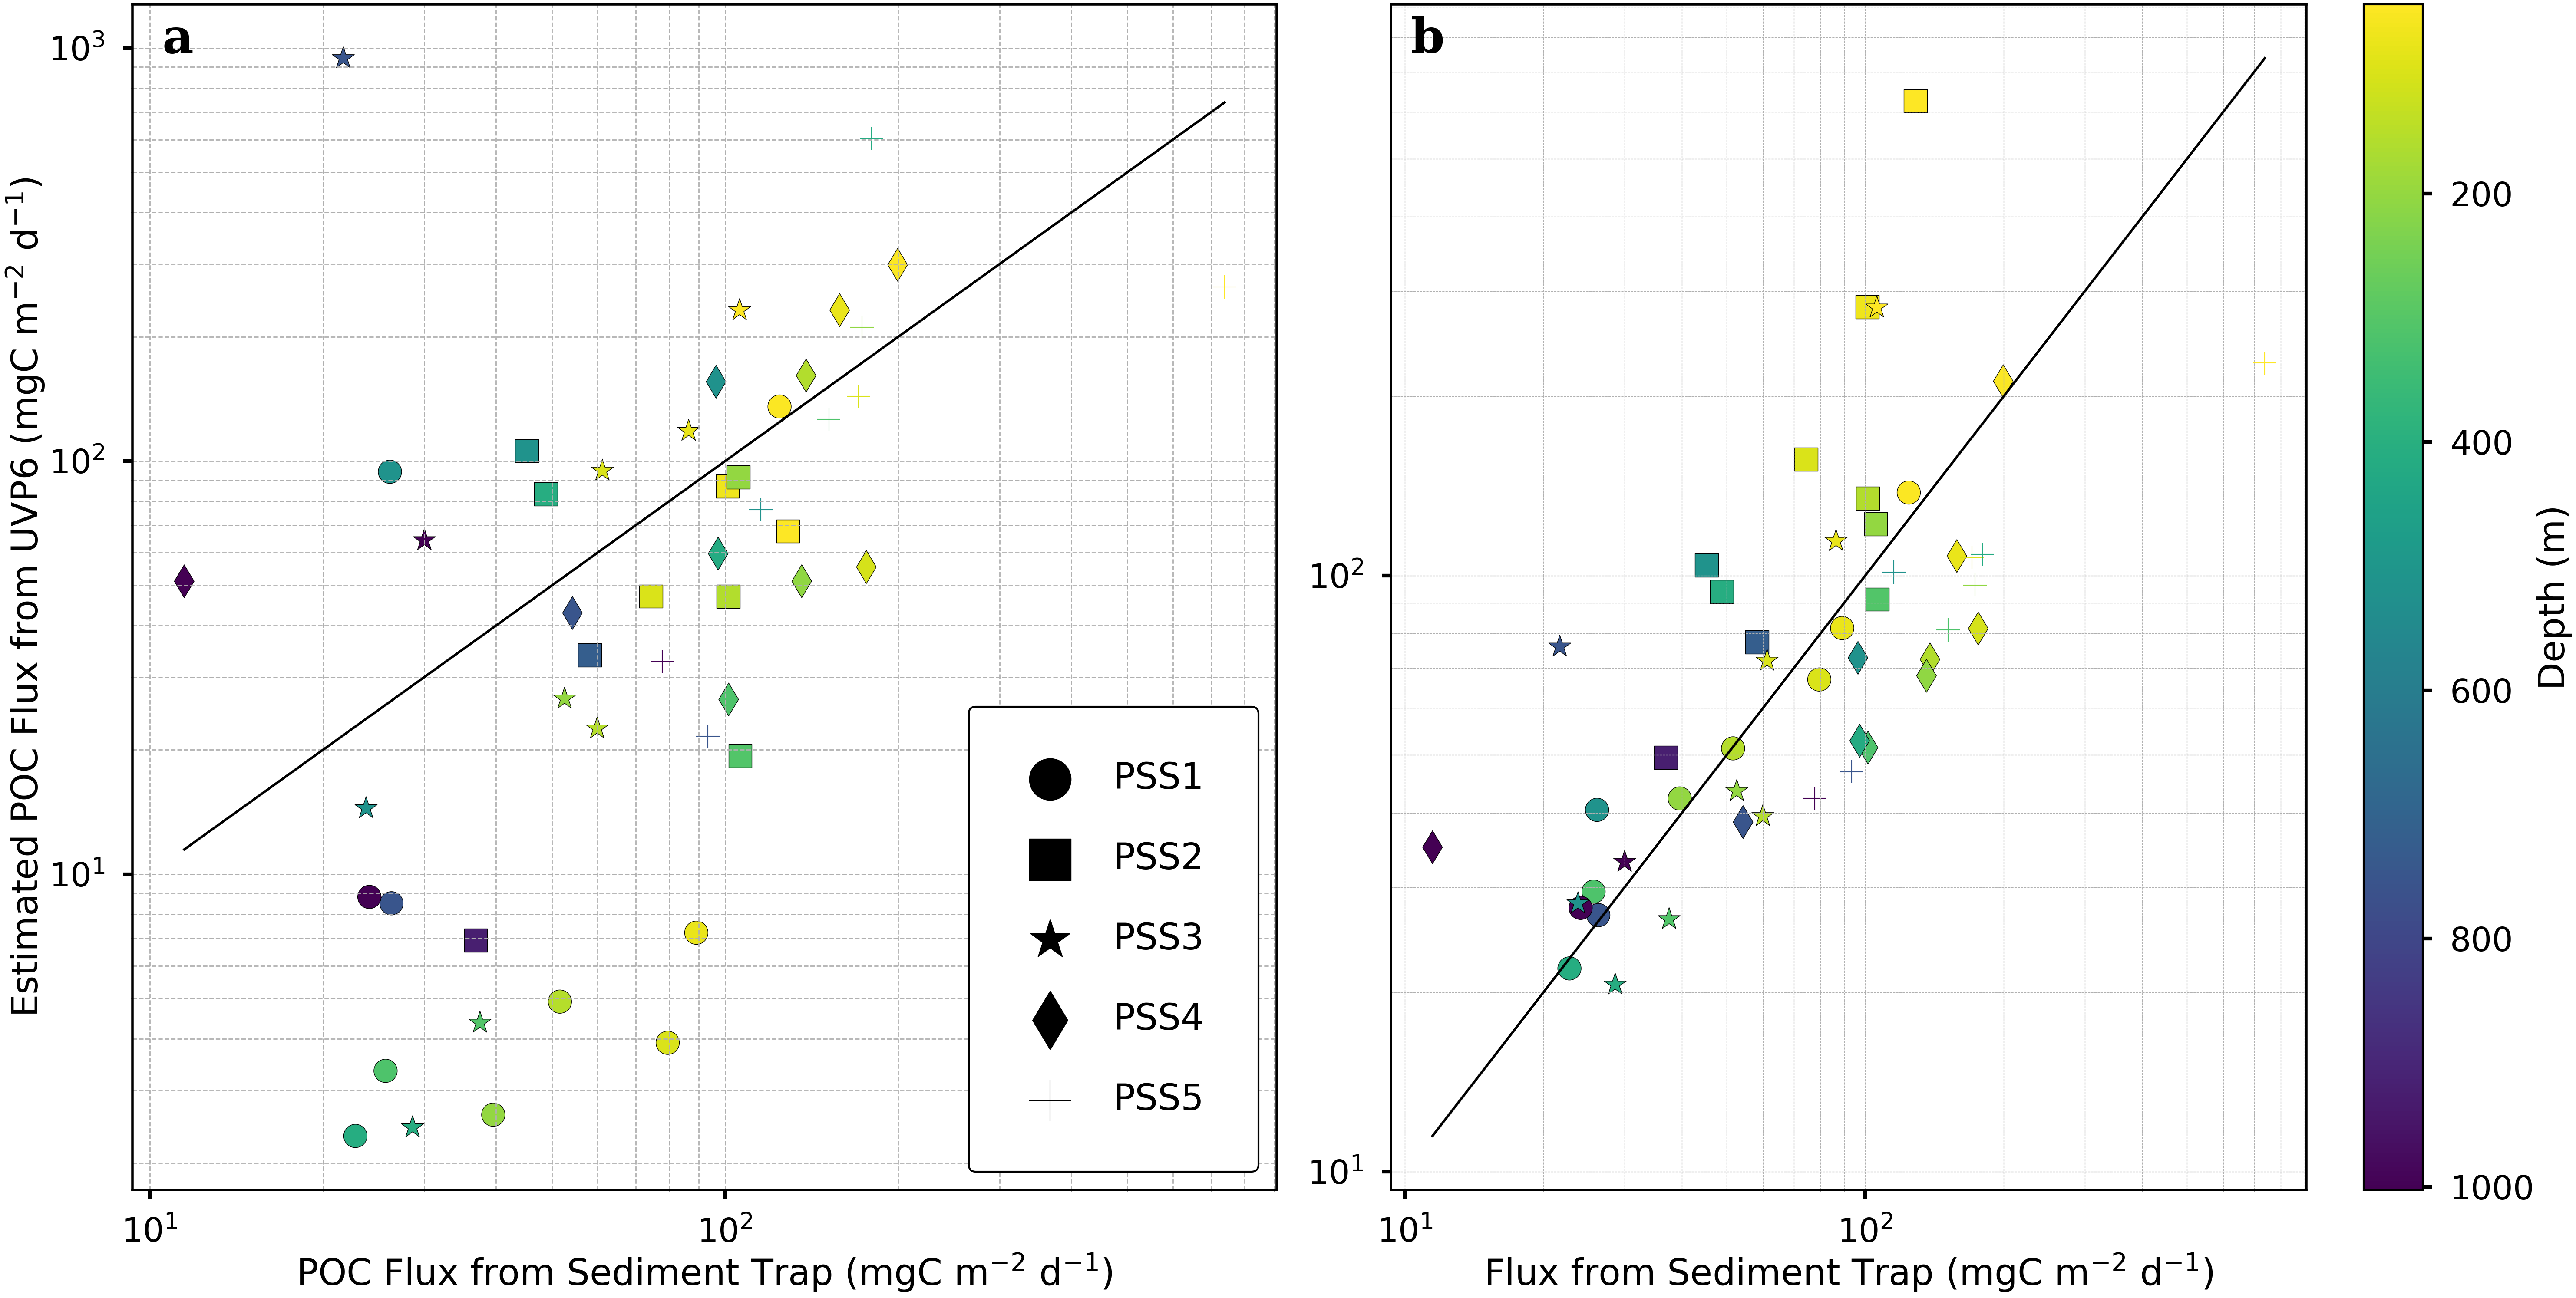

In [19]:
import os 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.animation import FuncAnimation
import math

import matplotlib as mplt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime
from matplotlib import cm
from matplotlib.colors import Normalize

from datetime import timedelta
from matplotlib.ticker import FuncFormatter
from matplotlib import ticker
from matplotlib import colors

# import uvp optimized fluxes data
uvp_optimized_vs_trap = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/calculated_fluxes_with_optimized_A_b.csv', delimiter = ",")

uvp_optimized_vs_trap.head(5)

# import uvp Guidi fluxes data
uvp_guidi_vs_trap = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/calculated_fluxes_with_optimized_A_b.csv', delimiter = ",")

uvp_guidi_vs_trap.head(5)

uvp_optimized_vs_trap['Site'].unique()

site_mapping = {
    'ST01_PSS1': 'PSS1',
    'ST11_PSS2': 'PSS2',
    'ST25_PSS3': 'PSS3',
    'ST32_PSS4': 'PSS4',
    'ST42_PSS5':'PSS5'
}

# Replace the values in the 'Site' column
uvp_optimized_vs_trap['Site'] = uvp_optimized_vs_trap['Site'].map(site_mapping)
uvp_guidi_vs_trap['Site'] = uvp_guidi_vs_trap['Site'].map(site_mapping)

# Set up the figure and subplots
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(60, 30))  # Create a figure with 1 row, 2 columns

# First subplot: Optimized A and b
stations = uvp_optimized_vs_trap['Site'].unique()
markers = ['o', 's', '*', 'd', '+']  # You can add more marker types as needed
station_marker_map = {station: marker for station, marker in zip(stations, markers)}

# Normalize the 'Pressure [dbar]' values for the color map
norm = plt.Normalize(uvp_optimized_vs_trap['Pressure [dbar]'].min(), uvp_optimized_vs_trap['Pressure [dbar]'].max())
cmap = plt.cm.viridis_r  # Use the 'viridis' colormap

for station in stations:
    df_station = uvp_optimized_vs_trap[uvp_optimized_vs_trap['Site'] == station]
    scatter = ax1.scatter(df_station['Mean_flux_trap_mgC_m2_j'],
                          df_station['Flux_guidi_mgC_m2'], 
                          c=df_station['Pressure [dbar]'],  
                          cmap=cmap,  
                          norm=norm, 
                          marker=station_marker_map[station],
                          s=1500, edgecolor='black')
    # Add scatter plot for legend with black markers
    ax1.scatter([], [], color='black', label=f'{station}', marker=station_marker_map[station], s=300)

# Add the 1:1 line to the first subplot
x_vals = np.logspace(np.log10(uvp_optimized_vs_trap['Mean_flux_trap_mgC_m2_j'].min()), np.log10(uvp_optimized_vs_trap['Mean_flux_trap_mgC_m2_j'].max()), 100)
ax1.plot(x_vals, x_vals, color='black', linewidth=4)

# Log scale for both axes
ax1.set_xscale('log')
ax1.set_yscale('log')

# Labels and title for the first subplot
size = 60
pad = 30
#ax1.set_ylabel('Estimated Flux from UVP6 (mgC.m⁻².d⁻¹)', fontsize=size)
ax1.set_ylabel('', fontsize=size)
ax1.set_xlabel('Flux from Sediment Trap (mgC m$^{-2}$ d$^{-1}$)', fontsize=size)
#ax1.set_title('Optimized A and b (A = 45.1 ; b = 2.2)', fontsize=size, pad=pad)

l = 15
w = 6
ax1.tick_params(axis='y', labelsize=size-5, pad = pad, length=l, width=w)
ax1.tick_params(axis='x', labelsize=size-5, pad = pad, length=l, width=w)

# Add color bar for the first plot
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Depth (m)', fontsize=size)
cbar1.ax.invert_yaxis()
cbar1.ax.tick_params(labelsize=size-5, pad = pad, length=l, width=w)
# Increase colorbar border width
for spine in cbar1.ax.spines.values():
    spine.set_linewidth(3) 
# Show legend and grid for the first plot
#ax1.legend(labelspacing=1.5)
ax1.grid(True, which="both", ls="--", linewidth=1)

# subplot indice
ax1.text(0.04, 0.97, 'b', color='black', 
                 fontsize=size+20, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
                 alpha = 1, transform=ax1.transAxes)

# Second subplot: Guidi et al., 2008
stations = uvp_guidi_vs_trap['Site'].unique()
markers = ['o', 's', '*', 'd', '+']  
station_marker_map = {station: marker for station, marker in zip(stations, markers)}

# Normalize the 'Pressure [dbar]' values for the color map
norm = plt.Normalize(uvp_guidi_vs_trap['Pressure [dbar]'].min(), uvp_guidi_vs_trap['Pressure [dbar]'].max())
cmap = plt.cm.viridis_r  

for station in stations:
    df_station = uvp_guidi_vs_trap[uvp_guidi_vs_trap['Site'] == station]
    scatter = ax2.scatter(df_station['Mean_flux_trap_mgC_m2_j'],
                          df_station['Flux_guidi_mgC_m2'], 
                          c=df_station['Pressure [dbar]'],  
                          cmap=cmap,  
                          norm=norm,  
                          marker=station_marker_map[station],
                          s=1500, edgecolor='black')
    # Add scatter plot for legend with black markers
    ax2.scatter([], [], color='black', label=f'{station}', marker=station_marker_map[station], s=300)

# Add the 1:1 line to the second subplot
x_vals = np.logspace(np.log10(uvp_guidi_vs_trap['Mean_flux_trap_mgC_m2_j'].min()), np.log10(uvp_guidi_vs_trap['Mean_flux_trap_mgC_m2_j'].max()), 100)
ax2.plot(x_vals, x_vals, color='black', linewidth=4)

# Log scale for both axes
ax2.set_xscale('log')
ax2.set_yscale('log')

# Labels and title for the second subplot
ax2.set_ylabel('Estimated POC Flux from UVP6 (mgC m$^{-2}$ d$^{-1}$)', fontsize=size)
ax2.set_xlabel('POC Flux from Sediment Trap (mgC m$^{-2}$ d$^{-1}$)', fontsize=size)
#ax2.set_title('A and b from Guidi et al., 2008 (A = 12.5 ; b = 3.81)', fontsize=size, pad=pad)
ax2.tick_params(axis='y', labelsize=size-5, pad = pad, length=l, width=w)
ax2.tick_params(axis='x', labelsize=size-5, pad = pad, length=l, width=w)
# subplot indice
ax2.text(0.04, 0.97, 'a', color='black', 
                 fontsize=size+20, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
                 alpha = 1, transform=ax2.transAxes)
# Add color bar for the second plot
#cbar2 = plt.colorbar(scatter, ax=ax2)
#cbar2.set_label('Pressure [dbar]', fontsize=size)
#cbar2.ax.invert_yaxis()
#cbar2.ax.tick_params(labelsize=size-5)


legend = ax2.legend(labelspacing=1.25, fontsize=60, markerscale=4, borderpad=1.5, #UVP_guidi
                         frameon = True, loc='lower right', ncol=1, edgecolor='black', 
                         handletextpad=1, handlelength=1.5, fancybox=True, shadow=False, framealpha=1)

legend.get_frame().set_linewidth(3)

ax2.grid(True, which="both", ls="--", linewidth=2, zorder = 1, alpha=1)

for ax in [ax1, ax2]:
    # Set the line width for all spines (top, bottom, left, right)
    for spine in ax.spines.values():
        spine.set_linewidth(4)

# Display the subplot figure
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S11/Figure_S11.png', dpi = 300)
plt.show()